In [17]:
#23 de junio
#Descubrir la dinámica de Lorenz a partir de una única medición parcial x_1 (añadiendo ruido) usando coordenadas de retardo (Time-Delay Embedding).  

In [18]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.integrate import solve_ivp
import pysindy as ps

In [19]:
#Modelo real del sistema de Lorenz
def lorenz(t,state,sigma=10, rho=28, beta=8/3):
    x,y,z = state
    return [sigma * (y - x), x * (rho - z) - y, x * y - beta * z]

In [20]:
#Genero datos reales de x (que equivale a x1)
dt = 0.01
t_span = (0, 50) #Empiezo en el segundo 0 y acabo en el 50
t_eval = np.arange(t_span[0], t_span[1], dt) #Vector que divide 0 a 50 en intervalos de 0.01 de longitud
x0 = [-8, 7, 27] #Inicializo el problema

sol = solve_ivp(lorenz, t_span, x0, t_eval=t_eval)
X_real = sol.y.T  # Dimensiones: (muestras, 3). Me devolvio el supuesto valor de x,y,z en 0,0.01,0.02,...,50
print("X_real=\n",X_real)
print(f"Forma de la matriz de soluciones reales X_real: {X_real.shape}")

# Fingimos que solo medimos la primera variable x (==x1) y le añadimos ruido
y_medido = X_real[:, 0] + np.random.normal(0, 0.05, size=len(t_eval))

X_real=
 [[ -8.           7.          27.        ]
 [ -6.58106657   6.81495487  25.79328661]
 [ -5.31708157   6.58547425  24.72174693]
 ...
 [ -5.57014667  -8.9938366   15.73928652]
 [ -5.92504552  -9.60194295  15.85234761]
 [ -6.30556508 -10.24001749  16.03388567]]
Forma de la matriz de soluciones reales X_real: (5000, 3)


In [21]:
#Creamos el espacio de retardos (embedding)
#El teorema de Taken dice que n>2m y en este caso m=3, por lo que n debería ser 7
#Sin embargo, como conozco el modelo de Lorenz (se supone que no), n=3 bastará porque corresponde a las 3 variables del sistema
n_delays = 3   # Dimensión de incrustación (creamos z1, z2, z3)
tau = 10       # retraso temporal (delay)
#Estoy creando nuevas variables: z1 = y(t), z2 = y(t+10) e z3 = y(t+20) Recuerda que este tiempo t va desde 0 hasta 50

#X_delay es H matriz de Hankel del articulo pero traspuesta
r=len(y_medido) - (n_delays - 1) * tau
X_delay = np.zeros((r, n_delays))
#[ [y[0] y[10] y[20],,
#   y[1] y[11] y[21],
#    ................
#   y[4979] y[4989] y[4999] ]  No existe y[5000]
for i in range(n_delays):
    X_delay[:, i] = y_medido[i * tau : r + i * tau]  #En la columna i, meto los datos de y desde i*tau hasta r+i*tau

# El tiempo correspondiente al recorte del embedding
t_delay = t_eval[0 : X_delay.shape[0]] #Me quedo con el vector [0.0, 0.01, 0.02, ..., 49.79].

In [22]:
#No voy a transformar el vector h en z utilizando un encoder y, por tanto, tampoco reduzo la dimension del problema. 
#Le meto directamente todos los datos (aunque son muchos) 
#Sin embargo, como no usé un encoder(como SVD), no limpié los datos y el problema es sensible al ruido
#Creo que puedo decir que usé un encoder trivial
model = ps.SINDy(feature_library=ps.PolynomialLibrary(degree=2), 
                 optimizer=ps.STLSQ(threshold=0.05))
model.fit(X_delay, t=dt)

# Ecuaciones analíticas descubiertas
print("\n--- ECUACIONES DINÁMICAS DESCUBIERTAS EN EL ESPACIO DE RETARDO (H) ---")
model.print()

#EL SISTEMA ES LIGERAMENTE DISTINTO AL QUE NO TIENE RUIDO.
#¿DEBERIA AÑADIR MÁS RUIDO PARA QUE LA SIMULACIÓN SALGA MAL?


--- ECUACIONES DINÁMICAS DESCUBIERTAS EN EL ESPACIO DE RETARDO (H) ---
(x0)' =  0.721 1 + -11.126 x0 +  15.925 x1 + -4.487 x2 + -0.070 x0^2 +  0.248 x0 x1 + -0.089 x0 x2 + -0.168 x1^2 +  0.084 x1 x2
(x1)' = -5.912 x0 +  5.911 x2
(x2)' = -0.523 1 +  4.452 x0 + -15.834 x1 +  11.086 x2


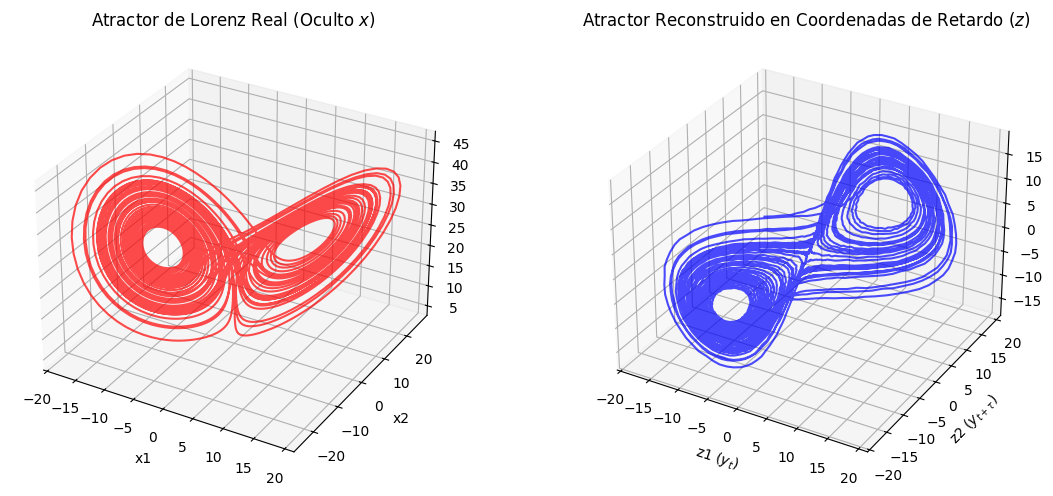

In [23]:
# Visualización del Atractor Reconstruido
fig = plt.figure(figsize=(12, 5))

# Atractor Real Completo (Al que no tenemos acceso en la realidad)
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(X_real[:, 0], X_real[:, 1], X_real[:, 2], color='r', alpha=0.7)
ax1.set_title("Atractor de Lorenz Real (Oculto $x$)")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")

# Atractor Reconstruido por el Embedding de Retardo (Espacio H )
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(X_delay[:, 0], X_delay[:, 1], X_delay[:, 2], color='b', alpha=0.7)
ax2.set_title("Atractor Reconstruido en Coordenadas de Retardo (H)")
ax2.set_xlabel("z1 ($y_t$)")
ax2.set_ylabel("z2 ($y_{t+\\tau}$)")

plt.tight_layout()
plt.show()